In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("datos_laterales.csv")
df

,jugador,equipo,minutos,gf_campo,gc_campo,gf_equipo_total,gc_equipo_total,partidos_equipo,puntos_equipo,plus_minus,plus_minus_90,tiros,cruces,intercepciones,tackles_ganados
0,Pablo Maffeo,Mallorca,2662,37,41,47,57,25,24,-4,-0.14,7,85,33,34
1,Arnau Martínez,Girona,2666,34,35,39,55,25,30,-1,-0.03,19,50,37,39


In [2]:
df['gf_90'] = df['gf_campo'] / df['minutos'] * 90
df['gc_90'] = df['gc_campo'] / df['minutos'] * 90
df['net_90'] = df['gf_90'] - df['gc_90']
df[['jugador', 'gf_90', 'gc_90', 'net_90']].round(2)


,jugador,gf_90,gc_90,net_90
0,Pablo Maffeo,1.25,1.39,-0.14
1,Arnau Martínez,1.15,1.18,-0.03


In [7]:
df['ppp_equipo'] = df['puntos_equipo'] / df['partidos_equipo']
df[['jugador', 'equipo', 'puntos_equipo', 'partidos_equipo',
'ppp_equipo']].round(2)


,jugador,equipo,puntos_equipo,partidos_equipo,ppp_equipo
0,Pablo Maffeo,Mallorca,24,25,0.96
1,Arnau Martínez,Girona,30,25,1.20


In [8]:
df['tiros_90'] = df['tiros'] / df['minutos'] * 90
df[['jugador', 'tiros', 'minutos', 'tiros_90']].round(2)

,jugador,tiros,minutos,tiros_90
0,Pablo Maffeo,7,2662,0.24
1,Arnau Martínez,19,2666,0.64


In [9]:
df[['jugador', 'plus_minus', 'plus_minus_90', 'cruces',
'intercepciones', 'tackles_ganados']]


,jugador,plus_minus,plus_minus_90,cruces,intercepciones,tackles_ganados
0,Pablo Maffeo,-4,-0.14,85,33,34
1,Arnau Martínez,-1,-0.03,50,37,39


In [11]:
df['cruces_90'] = df['cruces'] / df['minutos'] * 90
df['intercepciones_90'] = df['intercepciones'] / df['minutos'] * 90
df['tackles_90'] = df['tackles_ganados'] / df['minutos'] * 90

df[['jugador', 'cruces_90', 'intercepciones_90', 'tackles_90']].round(2)

,jugador,cruces_90,intercepciones_90,tackles_90
0,Pablo Maffeo,2.87,1.12,1.15
1,Arnau Martínez,1.69,1.25,1.32


In [12]:
resumen = df[[
 'jugador', 'equipo', 'net_90', 'plus_minus_90', 'ppp_equipo',
 'tiros_90', 'cruces_90', 'intercepciones_90', 'tackles_90'
]].round(2)
resumen


,jugador,equipo,net_90,plus_minus_90,ppp_equipo,tiros_90,cruces_90,intercepciones_90,tackles_90
0,Pablo Maffeo,Mallorca,-0.14,-0.14,0.96,0.24,2.87,1.12,1.15
1,Arnau Martínez,Girona,-0.03,-0.03,1.20,0.64,1.69,1.25,1.32


In [13]:
MINUTOS_TEMPORADA = 38 * 90

df['minutos_fuera'] = MINUTOS_TEMPORADA - df['minutos']
df['gf_fuera'] = df['gf_equipo_total'] - df['gf_campo']
df['gc_fuera'] = df['gc_equipo_total'] - df['gc_campo']

df['gf_90_fuera'] = (df['gf_fuera'] / df['minutos_fuera'].replace(0, pd.NA)) * 90
df['gc_90_fuera'] = (df['gc_fuera'] / df['minutos_fuera'].replace(0, pd.NA)) * 90

df['on_off_gf'] = df['gf_90'] - df['gf_90_fuera']
df['on_off_gc'] = df['gc_90'] - df['gc_90_fuera']
df['on_off_net'] = df['on_off_gf'] - df['on_off_gc']

df[['jugador', 'on_off_gf', 'on_off_gc', 'on_off_net']].round(2)

,jugador,on_off_gf,on_off_gc,on_off_net
0,Pablo Maffeo,0.06,-0.51,0.58
1,Arnau Martínez,0.55,-1.21,1.76


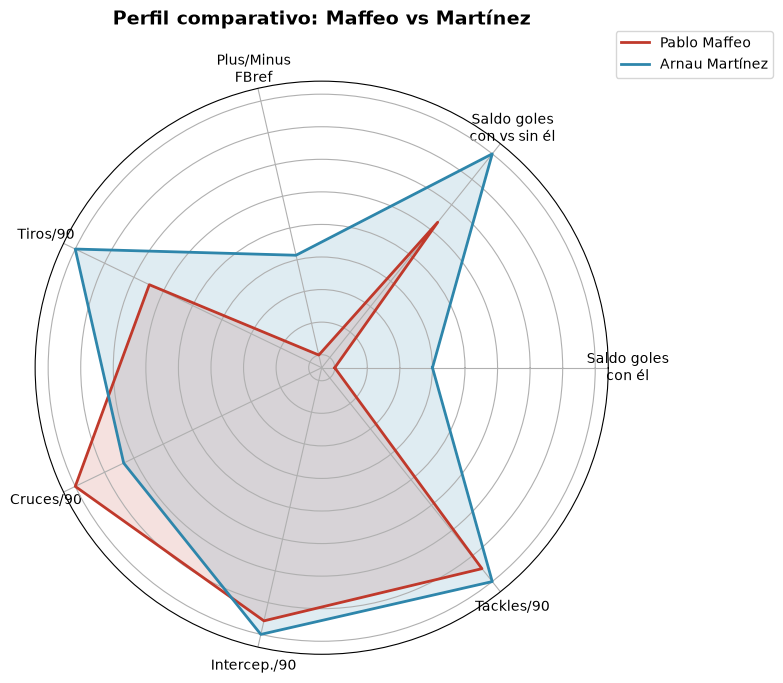

In [18]:
import numpy as np

metricas = ['net_90', 'on_off_net', 'plus_minus_90', 'tiros_90', 'cruces_90', 'intercepciones_90', 'tackles_90']
etiquetas = ['Saldo goles\ncon él', 'Saldo goles\ncon vs sin él', 'Plus/Minus\nFBref', 'Tiros/90', 'Cruces/90', 'Intercep./90', 'Tackles/90']

maffeo = df[df['jugador'] == 'Pablo Maffeo'][metricas].values.flatten()
martinez = df[df['jugador'] == 'Arnau Martínez'][metricas].values.flatten()

# Normalizamos cada métrica a escala 0-1 para que el radar no lo domine la de mayor magnitud
maximos = np.maximum(np.abs(maffeo), np.abs(martinez))
maximos[maximos == 0] = 1  # evita dividir por cero si alguna métrica fuera 0 en ambos
maffeo_norm = maffeo / maximos
martinez_norm = martinez / maximos

# El radar necesita "cerrar el círculo": repetimos el primer valor al final
angulos = np.linspace(0, 2 * np.pi, len(metricas), endpoint=False).tolist()
angulos += angulos[:1]
maffeo_plot = list(maffeo_norm) + [maffeo_norm[0]]
martinez_plot = list(martinez_norm) + [martinez_norm[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angulos, maffeo_plot, color='#C0392B', linewidth=2, label='Pablo Maffeo')
ax.fill(angulos, maffeo_plot, color='#C0392B', alpha=0.15)

ax.plot(angulos, martinez_plot, color='#2E86AB', linewidth=2, label='Arnau Martínez')
ax.fill(angulos, martinez_plot, color='#2E86AB', alpha=0.15)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_yticklabels([])  # quitamos los números del radio, no aportan aquí (está normalizado)
ax.set_title('Perfil comparativo: Maffeo vs Martínez', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('grafico_radar.png', dpi=150)
plt.show()

## Interpretación del perfil comparativo

### Aportación ofensiva

- **Generación de centros (Cruces/90):** Maffeo destaca claramente sobre
  Martínez (2,87 vs. 1,69), un perfil de lateral centrado en ganar la
  banda y buscar el área mediante centros.
- **Llegada y remate (Tiros/90):** Martínez supera con claridad a Maffeo
  en volumen de disparos (0,64 vs. 0,24), lo que sugiere mayor presencia
  en zonas interiores de remate o más incorporación al ataque por dentro.

### Rendimiento defensivo

- **Entradas e intercepciones (Tackles/90 e Intercep./90):** ambos
  laterales registran cifras altas de actividad defensiva, pero Martínez
  obtiene una ligera ventaja en las dos métricas (1,32 vs. 1,15 tackles;
  1,25 vs. 1,12 intercepciones), mostrando algo más de efectividad en el
  corte y la recuperación de balón.

### Impacto colectivo y métricas Plus/Minus

- **Efecto en el equipo (Saldo goles con vs. sin él):** aquí está la
  diferencia más marcada del análisis. Ambos jugadores tienen un impacto
  positivo — su equipo rinde mejor con ellos en el campo que sin ellos —
  pero el de Martínez es notablemente mayor (+1,76 frente a +0,58 de
  Maffeo).
- **Saldo directo del marcador (Plus/Minus FBref y saldo de goles con
  él):** en estas dos métricas ninguno de los dos está en positivo — el
  equipo encaja algo más de lo que marca mientras ambos juegan — pero
  Martínez se mantiene más cerca del equilibrio (-0,03 vs. -0,14 de
  Maffeo). Tiene sentido: mide el resultado bruto del partido, más
  condicionado por el rendimiento general del equipo que por el jugador
  en sí, y ninguno de los dos milita en un equipo dominante esta
  temporada.

### Resumen del perfil comparativo

- **Pablo Maffeo:** perfil tradicional de banda — más centrador que
  rematador, con una contribución defensiva sólida pero algo por debajo
  de Martínez en las métricas de recuperación.
- **Arnau Martínez:** perfil más orientado a asociarse por dentro y
  llegar al remate, ligeramente superior en las métricas defensivas, y
  con el impacto colectivo (on/off) más determinante de los dos —
  aunque conviene leer esta última cifra con cautela: con un solo equipo
  de referencia y una muestra de temporada, puede estar influida por
  otros factores además del propio jugador (lesiones de compañeros,
  calendario, etc.).